## 1) Installation

In [1]:
!pip install -q "trl==0.29.1" peft
!pip uninstall -y -q torchao

## 2)GPU

In [2]:

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"   # ← nouvelle ligne
!rm -rf llm_pii_anonymizer_fr
!git clone https://github.com/ellakonan41/llm_pii_anonymizer_fr.git
import sys
sys.path.append("llm_pii_anonymizer_fr")

import glob, json, random
from src.annotation import charger_annotations
from src.cleaning import est_valide, normaliser_etiquettes, tirer_echantillon
from src.dpo import generer_exemples, choisir_rejet, paire_dpo
from src.generation import anonymiser
from src.evaluation import evaluer, evaluer_exemple

def lire(nom):
    with open(glob.glob(f"/kaggle/input/**/{nom}", recursive=True)[0], encoding="utf-8") as f:
        return [json.loads(l) for l in f]

Cloning into 'llm_pii_anonymizer_fr'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (97/97), done.)
remote: Compressing objects: 100% (69/69), done.
remote: Total 97 (delta 45), reused 76 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (97/97), 201.89 KiB | 2.02 MiB/s, done.
Resolving deltas: 100% (45/45), done.


## 3)les textes d'entraînement du DPO

In [3]:
from datasets import load_dataset

# 1. Textes ciblés, générés par gabarits (formats français, rues en mots courants)
cibles = generer_exemples(800, graine=0)

# 2. Textes généraux d'ai4privacy, jamais vus : ni dans train_v1, ni dans le test
deja_utilises = {ex["uid"] for ex in lire("train_v1.jsonl")} | {ex["uid"] for ex in lire("test.jsonl")}
ds = load_dataset("ai4privacy/open-pii-masking-500k-ai4privacy", split="train")
ds = ds.filter(lambda ex: ex["language"] == "fr").select_columns(["uid", "source_text", "masked_text", "privacy_mask"])
generaux = []
for ex in ds.to_list():
    if ex["uid"] in deja_utilises or not est_valide(ex):
        continue
    if any(e["label"] == "STREET" for e in ex["privacy_mask"]):
        continue
    ex["masked_text"] = normaliser_etiquettes(ex["masked_text"])
    generaux.append(ex)
generaux = tirer_echantillon(generaux, 400, graine=7)

exemples_dpo = cibles + generaux
print(len(cibles), "ciblés +", len(generaux), "généraux =", len(exemples_dpo))

800 ciblés + 400 généraux = 1200


## 4)charger la v1 et récolter ses vraies erreurs

In [4]:
import copy, torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

NOM_MODELE = "Qwen/Qwen2.5-0.5B-Instruct"
tok = AutoTokenizer.from_pretrained(NOM_MODELE)
tok.padding_side = "left"

chemin_lora_v1 = os.path.dirname(glob.glob("/kaggle/input/**/lora_v1/adapter_config.json", recursive=True)[0])
base = AutoModelForCausalLM.from_pretrained(NOM_MODELE, dtype=torch.float32, device_map="cuda")
model_v1 = PeftModel.from_pretrained(base, chemin_lora_v1).merge_and_unload()

model_gen = copy.deepcopy(model_v1).to(torch.float16).eval()
sorties_v1_dpo = anonymiser(model_gen, tok, [ex["source_text"] for ex in exemples_dpo])
del model_gen
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


## 5)construire les paires

In [5]:
from collections import Counter
from datasets import Dataset

rng = random.Random(0)
paires, origines = [], Counter()
for ex, sortie in zip(exemples_dpo, sorties_v1_dpo):
    choix = choisir_rejet(ex, sortie, rng)
    if choix is None:
        continue
    rejet, origine = choix
    paires.append(paire_dpo(ex, rejet))
    origines[origine] += 1

print(len(paires), "paires :", dict(origines))
for p in paires[:3]:
    print("\nCHOSEN  :", p["chosen"][0]["content"])
    print("REJECTED:", p["rejected"][0]["content"])

ds_dpo = Dataset.from_list(paires).train_test_split(test_size=100, seed=42)
train_dpo, eval_dpo = ds_dpo["train"], ds_dpo["test"]

1200 paires : {'modele': 335, 'fuite': 452, 'en_trop': 204, 'faute': 209}

CHOSEN  : Le marché de [CITY] se tient [STREET] chaque vendredi matin.
REJECTED: Le marché de [CITY] se tient avenue des Fleurs chaque vendredi matin.

CHOSEN  : Le départ du car est fixé à [TIME] le [DATE], devant la mairie de [CITY].
REJECTED: Le départ du car est fixé à [TIME] le [DATE], devant la mairie de Metz.

CHOSEN  : Visite de l'appartement du [BUILDINGNUM] [STREET] prévue samedi [DATE] à [TIME]. Contact agence : [GIVENNAME] [SURNAME], [TELEPHONENUM].
REJECTED: Visite de l'appartement du [BUILDINGNUM] chemin de la Forêt prévue samedi 26 octobre 2024 à 8h10. Contact agence : [GIVENNAME] [SURNAME], [TELEPHONENUM].


## 6)configurer le DPO

In [6]:
from peft import LoraConfig
from trl import DPOConfig, DPOTrainer

lora_config = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    task_type="CAUSAL_LM",
)

config = DPOConfig(
    output_dir="/kaggle/working/dpo_v3",
    num_train_epochs=1,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=2e-5,
    lr_scheduler_type="cosine",
    warmup_steps=5,
    beta=0.1,
    loss_type=["sigmoid", "sft"],
    max_length=640,
    fp16=True,
    bf16=False,
    logging_steps=5,
    eval_strategy="steps",
    eval_steps=20,
    per_device_eval_batch_size=2,
    save_strategy="no",
    report_to="none",
    seed=42,
)

trainer = DPOTrainer(
    model=model_v1,
    args=config,
    train_dataset=train_dpo,
    eval_dataset=eval_dpo,
    processing_class=tok,
    peft_config=lora_config,
)
trainer.model.print_trainable_parameters()

Tokenizing train dataset:   0%|          | 0/1100 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


## 7)entraîner 

In [7]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
20,0.469833,0.453224
40,0.338874,0.301408
60,0.208395,0.262240


TrainOutput(global_step=69, training_loss=0.39471568663914997, metrics={'train_runtime': 371.3484, 'train_samples_per_second': 2.962, 'train_steps_per_second': 0.186, 'total_flos': 1235531912755200.0, 'train_loss': 0.39471568663914997})

## 8)Courbes

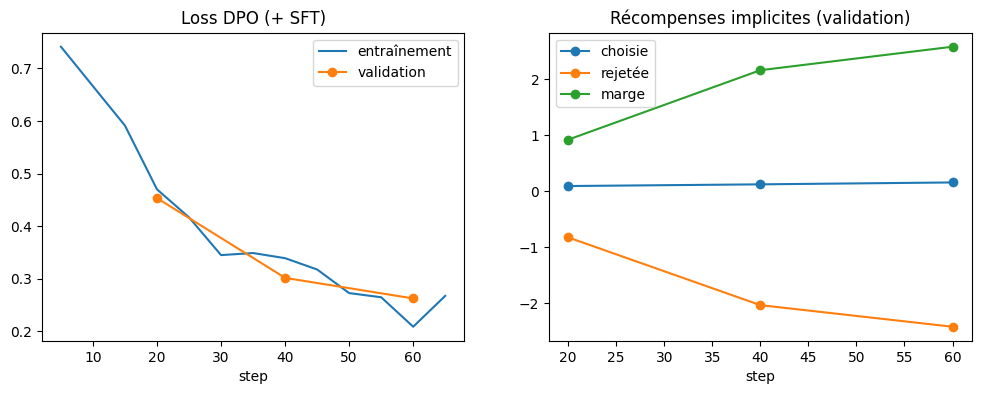

 step  eval_rewards/accuracies  eval_rewards/margins
   20                     0.91              0.917165
   40                     0.93              2.157221
   60                     0.92              2.576534


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

h = pd.DataFrame(trainer.state.log_history)
ev = h.dropna(subset=["eval_loss"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tr = h.dropna(subset=["loss"])
axes[0].plot(tr["step"], tr["loss"], label="entraînement")
axes[0].plot(ev["step"], ev["eval_loss"], marker="o", label="validation")
axes[0].set_title("Loss DPO (+ SFT)"); axes[0].set_xlabel("step"); axes[0].legend()
axes[1].plot(ev["step"], ev["eval_rewards/chosen"], marker="o", label="choisie")
axes[1].plot(ev["step"], ev["eval_rewards/rejected"], marker="o", label="rejetée")
axes[1].plot(ev["step"], ev["eval_rewards/margins"], marker="o", label="marge")
axes[1].set_title("Récompenses implicites (validation)"); axes[1].set_xlabel("step"); axes[1].legend()
plt.savefig("/kaggle/working/dpo_v3.png", dpi=120, bbox_inches="tight")
plt.show()
print(ev[["step", "eval_rewards/accuracies", "eval_rewards/margins"]].to_string(index=False))

## 9)sauvegarder l'adaptateur

In [9]:
trainer.save_model("/kaggle/working/lora_v3")

## 10)évaluer la v3 sur les deux tests et comparer

In [10]:
model_v3 = trainer.model.merge_and_unload().to(torch.float16)
model_v3.gradient_checkpointing_disable()
model_v3.config.use_cache = True
model_v3.eval()

test_synth = lire("test.jsonl")
test_reel = charger_annotations("llm_pii_anonymizer_fr/data/test_realiste.jsonl")

sorties_v3_synth = anonymiser(model_v3, tok, [ex["source_text"] for ex in test_synth])
sorties_v3_reel = anonymiser(model_v3, tok, [ex["source_text"] for ex in test_reel])
r3_synth = evaluer(test_synth, sorties_v3_synth)
r3_reel = evaluer(test_reel, sorties_v3_reel)

r1_synth = json.load(open(glob.glob("/kaggle/input/**/resultats_v1.json", recursive=True)[0]))
r1_reel = json.load(open(glob.glob("/kaggle/input/**/resultats_reel.json", recursive=True)[0]))["v1"]

print(f"{'métrique':<25} {'v1 synth':>9} {'v3 synth':>9} {'v1 réel':>9} {'v3 réel':>9}")
for cle in ["protection", "textes_sans_fuite", "preservation", "correspondance_exacte"]:
    print(f"{cle:<25} {r1_synth[cle]:>9.1%} {r3_synth[cle]:>9.1%} {r1_reel[cle]:>9.1%} {r3_reel[cle]:>9.1%}")

print(f"\n{'type (réel)':<20} {'n':>4} {'v1':>8} {'v3':>8}")
for label, n in r3_reel["effectifs_par_type"].items():
    print(f"{label:<20} {n:>4} {r1_reel['protection_par_type'][label]:>8.1%} {r3_reel['protection_par_type'][label]:>8.1%}")

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

métrique                   v1 synth  v3 synth   v1 réel   v3 réel
protection                    99.5%     99.9%     97.0%    100.0%
textes_sans_fuite             99.0%     99.8%     88.0%    100.0%
preservation                  99.7%     99.3%     99.5%     98.1%
correspondance_exacte         76.8%     68.0%     48.0%     54.0%

type (réel)             n       v1       v3
GIVENNAME              52   100.0%   100.0%
SURNAME                47   100.0%   100.0%
DATE                   24    95.8%   100.0%
TITLE                  21   100.0%   100.0%
CITY                   14   100.0%   100.0%
TIME                   12    83.3%   100.0%
TELEPHONENUM           11   100.0%   100.0%
BUILDINGNUM            10   100.0%   100.0%
STREET                 10    60.0%   100.0%
ZIPCODE                10   100.0%   100.0%
EMAIL                   7   100.0%   100.0%
AGE                     5   100.0%   100.0%
SOCIALNUM               4   100.0%   100.0%
CREDITCARDNUMBER        2   100.0%   100.0%
DRIVERLIC

## 11)les erreurs restantes de la v3 (test réaliste)

In [11]:
from src.evaluation import entite_protegee, mots_hors_donnees_personnelles

for ex, s in zip(test_reel, sorties_v3_reel):
    mots = frozenset(mots_hors_donnees_personnelles(ex))
    fuites = [f"{e['label']}={e['value']!r}" for e in ex["privacy_mask"] if not entite_protegee(e["value"], s, mots)]
    r = evaluer_exemple(ex, s)
    if fuites or r["nb_mots_conserves"] < r["nb_mots_attendus"]:
        print(ex["uid"])
        print("  ORIGINAL :", ex["source_text"])
        print("  MODÈLE   :", s)
        if fuites:
            print("  FUITES   :", ", ".join(fuites))
        if r["nb_mots_conserves"] < r["nb_mots_attendus"]:
            print(f"  MOTS PERDUS : {r['nb_mots_attendus'] - r['nb_mots_conserves']}")
        print("-" * 80)

reel-001
  ORIGINAL : Bonjour Madame Lefèvre, suite à notre échange d'hier, je vous confirme le rendez-vous du 14 novembre à 10h30 avec le Dr Martin. Pensez à apporter votre carte Vitale. Cordialement, Julie Bernard, secrétariat médical.
  MODÈLE   : Bonjour [TITLE] [SURNAME], suite à notre échange d'hier, je vous confirme le rendez-vous du [DATE] à [TIME] avec le [TITLE] [GIVENNAME]. Pensez à apporter votre carte [CITY]. Cordialement, [GIVENNAME], secrétariat médical.
  MOTS PERDUS : 1
--------------------------------------------------------------------------------
reel-004
  ORIGINAL : Le service sera fermé le lundi de Pâques. Les demandes reçues pendant cette période seront traitées dès la réouverture.
  MODÈLE   : Le service sera fermé le lundi de [DATE]. Les demandes reçues pendant cette période seront traitées dès la réouverture.
  MOTS PERDUS : 1
--------------------------------------------------------------------------------
reel-006
  ORIGINAL : Ordonnance du Dr Nadia Haddad p

## 12)sauvegarder

In [12]:
json.dump({"synthetique": r3_synth, "reel": r3_reel},
          open("/kaggle/working/resultats_v3.json", "w", encoding="utf-8"), ensure_ascii=False, indent=2)
with open("/kaggle/working/sorties_v3.jsonl", "w", encoding="utf-8") as f:
    for ex, s in zip(test_reel, sorties_v3_reel):
        f.write(json.dumps({"uid": ex["uid"], "sortie": s}, ensure_ascii=False) + "\n")